<a href="https://colab.research.google.com/github/Kshitiz83/Project-Market-Basket-Analysis-Uncovering-Purchase-Patterns-in-E-commerce-Data/blob/main/Market_Basket_Analysis_Uncovering_Purchase_Patterns_in_E_commerce_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROJECT-Market Basket Analysis:
Uncovering Purchase Patterns in E-commerce Data**

### Data Loading and Initial Inspection

This cell imports necessary libraries for data manipulation (`pandas`), numerical operations (`numpy`), and plotting (`matplotlib.pyplot`, `seaborn`). It then loads the 'online_retail_II.csv' dataset into a pandas DataFrame named `df` and displays the first 3 rows to provide a quick overview of the data structure and content.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/online_retail_II.csv")
df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


### Check Data Types

This cell inspects the data types of each column in the DataFrame (`df.dtypes`). This is a crucial step for understanding how to perform further operations, identifying columns that might need type conversion, and catching potential issues early in the data preparation process.

In [ ]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


### Feature Engineering (Date and Time Components)

This cell performs feature engineering on the `InvoiceDate` column. It first converts `InvoiceDate` to datetime objects to enable time-based operations. Then, it extracts various granular time-based features such as day, month, year, hour, minute, and day of the week, storing them in new columns. Finally, the original `InvoiceDate` column is dropped as its components have been extracted into separate, more usable features.

In [ ]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df["Date"]=df.InvoiceDate.dt.day
df['Month']=df.InvoiceDate.dt.month
df['Year']=df.InvoiceDate.dt.year
df['Hour']=df.InvoiceDate.dt.hour
df['Minute']=df.InvoiceDate.dt.minute
df['Day of Week']=df.InvoiceDate.dt.day_name()
df.drop(columns=['InvoiceDate'],inplace=True)
df.head(3)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Date,Month,Year,Hour,Minute,Day of Week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,1,12,2009,7,45,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,1,12,2009,7,45,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,1,12,2009,7,45,Tuesday


### Check for Missing Values (Initial)

This cell checks for missing values across all columns of the DataFrame (`df.isnull().sum()`). This step is essential in data cleaning to understand the extent of missing data and determine appropriate strategies for handling them, such as imputation or removal.

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
Price,0
Customer ID,243007
Country,0
Date,0
Month,0
Year,0


### Handle Missing 'Description' Values

This cell handles missing values by dropping rows where the 'Description' column is null (`df.dropna(subset=['Description'], inplace=True)`). Since 'Description' is critical for identifying individual items in market basket analysis, rows without this information are not useful for the analysis and are removed.

In [ ]:
df.dropna(subset=['Description'],inplace=True)

### Re-check Missing Values (After Description Cleanup)

This cell re-checks for missing values after dropping rows with null 'Description' (`df.isnull().sum()`). This confirms the effect of the previous cleaning operation and helps to identify any remaining missing values, particularly in the 'Customer ID' column, which might be addressed in later steps.

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
Price,0
Customer ID,238625
Country,0
Date,0
Month,0
Year,0


### Filter Out Invalid Transactions

This cell performs critical data cleaning by filtering out invalid or undesirable transactions. It keeps only those transactions where `Quantity` is positive (removing returns or errors) and removes invoices with IDs starting with 'C' (which typically denote canceled orders or returns). This ensures that only valid purchase transactions are included in the analysis.

In [ ]:
df=df[df['Quantity']>0]
df=df[~df['Invoice'].astype(str).str.startswith('C')]
df.head(3)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Date,Month,Year,Hour,Minute,Day of Week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,1,12,2009,7,45,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,1,12,2009,7,45,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,1,12,2009,7,45,Tuesday


First, let's identify how many rows have a `Quantity` that is negative or zero:

### Verify Quantity Filtering

This cell explicitly checks and prints the count of rows where the `Quantity` is less than or equal to zero (`(df['Quantity'] <= 0).sum()`). This serves as a verification step, ensuring that the previous filtering operation successfully removed all entries with non-positive quantities.

In [ ]:
print(f"Number of rows with Quantity <= 0: {(df['Quantity'] <= 0).sum()}")

Number of rows with Quantity <= 0: 0


Now, let's remove these rows from the DataFrame. We'll also remove invoices that start with 'C', as these also typically indicate cancellations or returns.

### Final Data Shape and Missing Value Check

This cell outputs the final shape of the DataFrame (number of rows and columns) after all cleaning and filtering operations (`print(df.shape)`). It then displays the sum of missing values per column again (`display(df.isnull().sum())`) to show the conclusive state of missing data before proceeding with analytical tasks.

In [ ]:

print(df.shape)
print("\nMissing values after cleaning:")
display(df.isnull().sum())

(1042727, 13)

Missing values after cleaning:


,0
Invoice,0
StockCode,0
Description,0
Quantity,0
Price,0
Customer ID,237107
Country,0
Date,0
Month,0
Year,0


### Visualize Top 10 Most Frequent Items

This cell identifies the top 10 most frequently purchased items based on their 'Description' column and visualizes their counts using a bar plot. This visualization helps to quickly highlight the most popular products in the dataset.

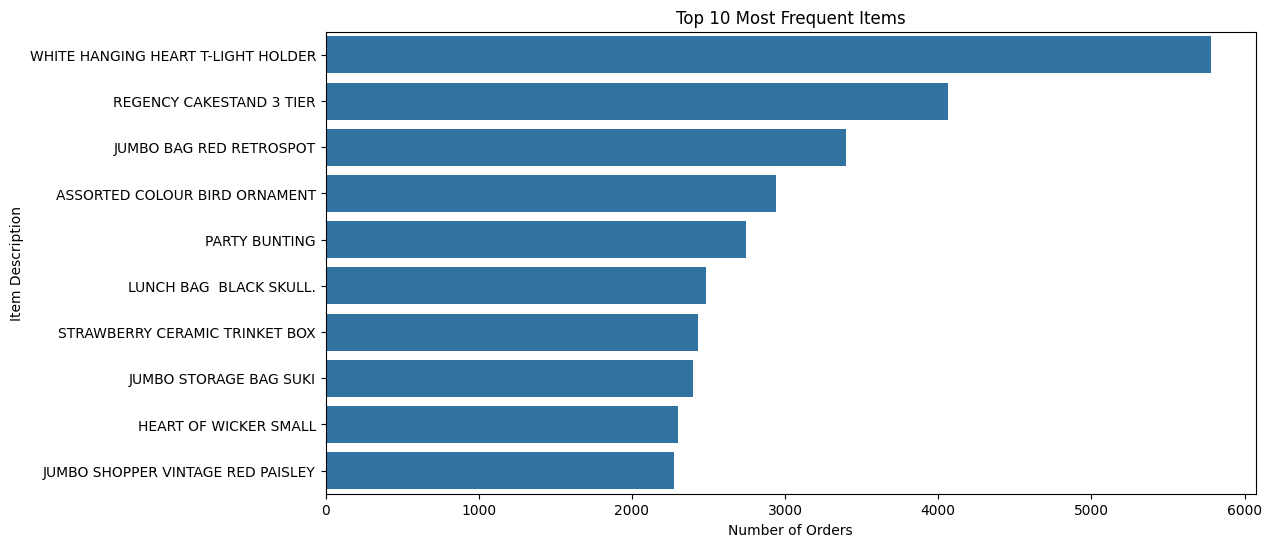

In [ ]:


top_items=df['Description'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_items.values,y=top_items.index)
plt.title('Top 10 Most Frequent Items')
plt.xlabel('Number of Orders')
plt.ylabel('Item Description')
plt.show()

### Visualize Most Sold Items by Total Price

This cell calculates the total sales revenue (sum of 'Price') for each item ('Description') and then visualizes the top 10 items that generated the highest total revenue using a bar plot. This helps identify products that are most valuable in terms of monetary contribution.

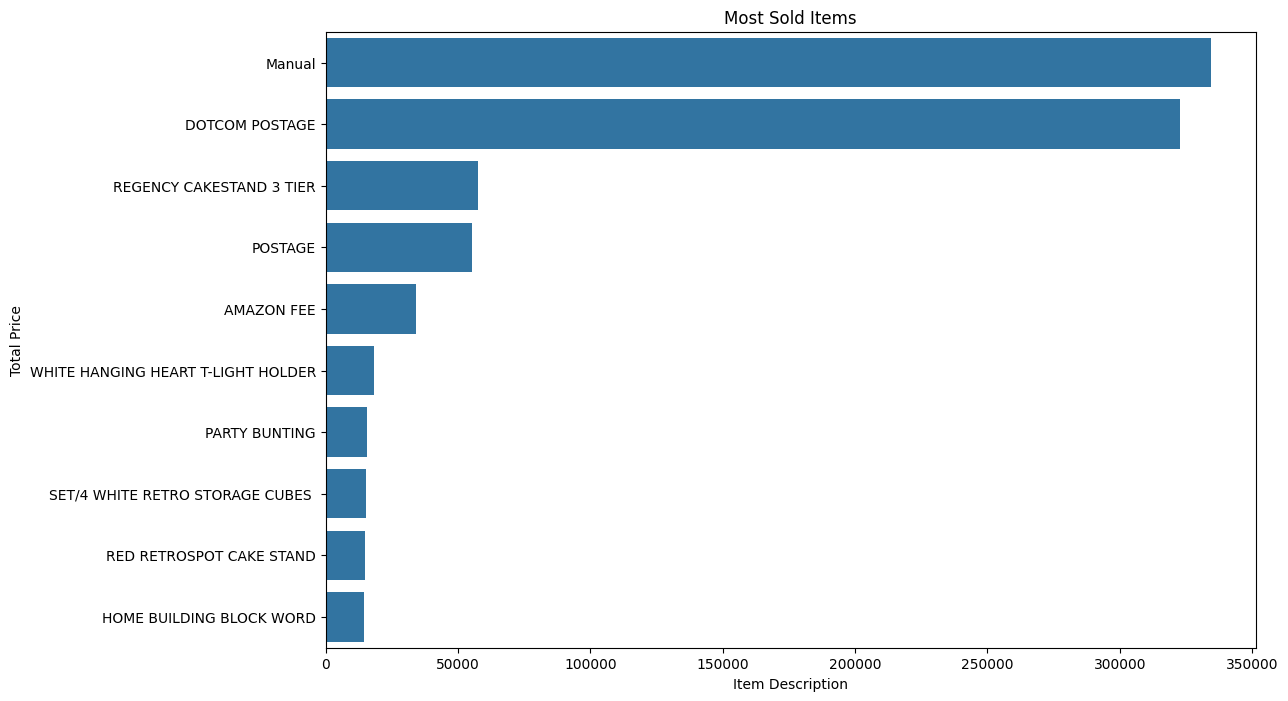

In [ ]:

most_solditems=df.groupby('Description')['Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,8))
sns.barplot(x=most_solditems.values,y=most_solditems.index)
plt.title("Most Sold Items")
plt.xlabel('Item Description')
plt.ylabel('Total Price')
plt.show()








### Visualize Daily Sales Trends

This cell aggregates the total 'Price' (sales) for each day and then visualizes these daily sales totals using a bar plot. This visualization provides an overview of sales performance on a daily basis, allowing for the observation of short-term trends or anomalies.

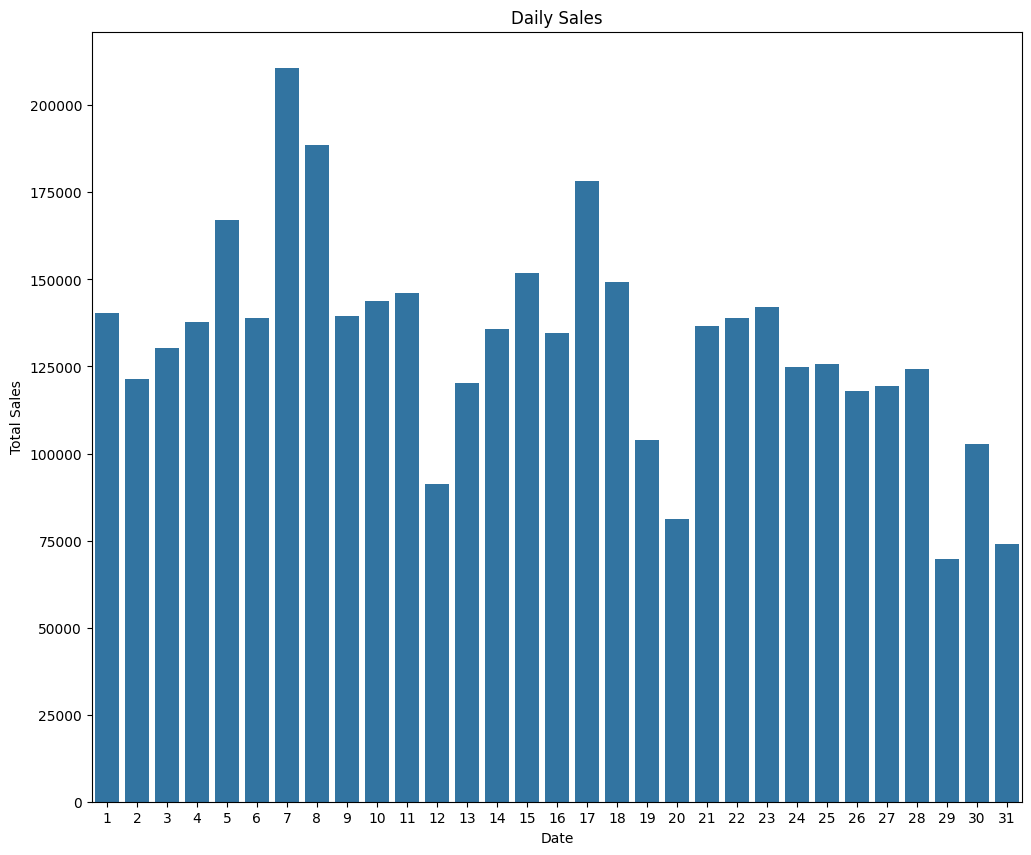

In [ ]:
daily_sales=df.groupby('Date')['Price'].sum()

plt.figure(figsize=(12,10))
sns.barplot(x=daily_sales.index,y=daily_sales.values)
plt.title('Daily Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()


### Prepare Data for Market Basket Analysis (One-Hot Encoding)

This cell prepares the transactional data for market basket analysis. It groups all 'Description' (items) by 'Invoice' (transaction) to create a list of items for each transaction. Then, it uses `mlxtend.preprocessing.TransactionEncoder` to perform one-hot encoding, transforming the transaction lists into a binary DataFrame where each row represents an invoice and each column represents an item, with `True` indicating presence and `False` absence.

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Group items by Invoice (transaction)
transactions = df.groupby('Invoice')['Description'].apply(list)

# Initialize TransactionEncoder
te = TransactionEncoder()

# One-hot encode the transactions
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

Now that we have the one-hot encoded DataFrame, we can calculate the co-occurrence matrix and visualize it as a heatmap.

### Generate and Visualize Co-occurrence Heatmap

This cell calculates the co-occurrence matrix from the one-hot encoded transaction DataFrame (`df_encoded`). It then filters this matrix to include only the top 20 most frequent items for clearer visualization. Finally, it generates a heatmap using `seaborn.heatmap` to visually represent which items are frequently purchased together, providing insights into product associations.

In [ ]:
# Calculate the co-occurrence matrix
co_occurrence_matrix = df_encoded.T.dot(df_encoded)

# Optionally, remove self-co-occurrences for better visualization
# for i in range(co_occurrence_matrix.shape[0]):
#     co_occurrence_matrix.iloc[i, i] = 0

# Select a subset of top items for clearer visualization if the matrix is too large
# For demonstration, let's pick some items based on frequency or just a sample
# For a real scenario, you might want to filter based on support/frequency

# Let's consider the top N most frequent items for the heatmap
top_n = 20 # Adjust as needed

top_items_list = df['Description'].value_counts().head(top_n).index.tolist()

# Filter the co-occurrence matrix to include only these top items
co_occurrence_filtered = co_occurrence_matrix.loc[top_items_list, top_items_list]

plt.figure(figsize=(16, 14))
sns.heatmap(co_occurrence_filtered, annot=False, cmap='viridis', fmt='g', linewidths=.5)
plt.title(f'Co-occurrence Heatmap of Top {top_n} Items')
plt.xlabel('Items')
plt.ylabel('Items')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Initial Monthly Sales Plot

This cell calculates the total sales ('Price') for each month and then visualizes these monthly totals using a bar plot. This provides an initial view of how sales are distributed across different months, though it doesn't explicitly ensure all 12 months are present or named.

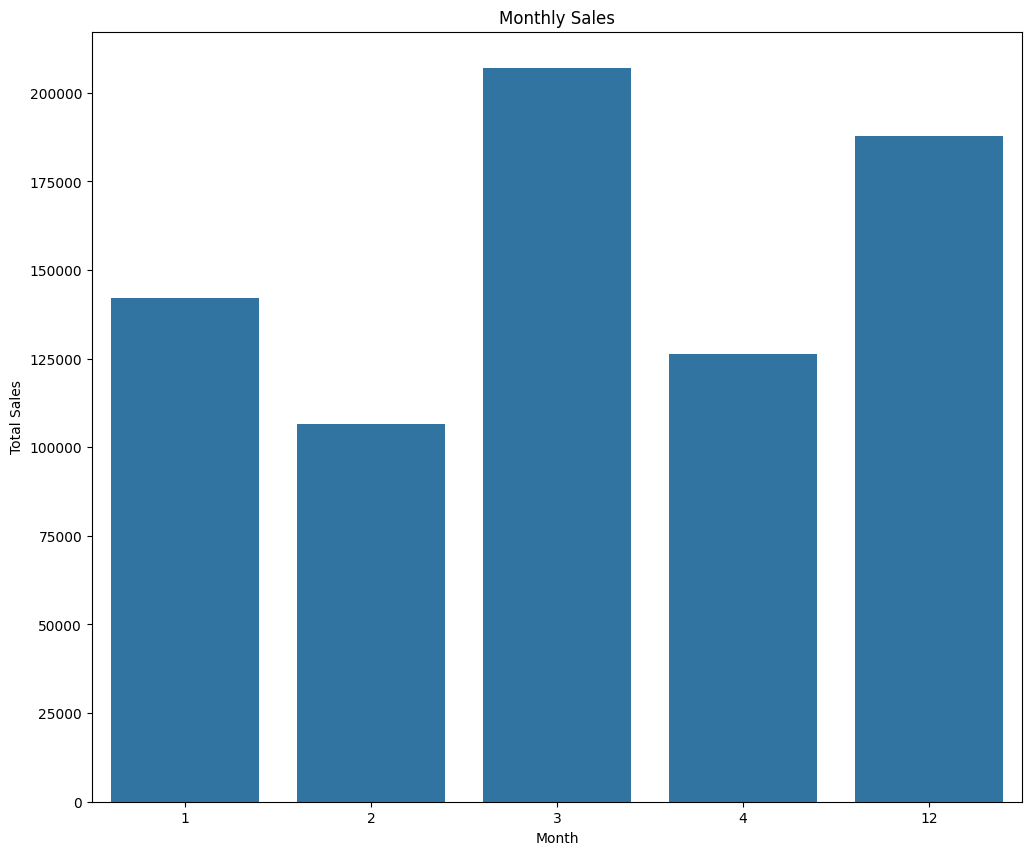

In [ ]:
month_sales=df.groupby('Month')['Price'].sum().reset_index()
plt.figure(figsize=(12,10))
sns.barplot(x="Month",y="Price",data=month_sales)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

### Refined Monthly Sales Plot (with All Months and Names)

This cell refines the monthly sales visualization. It first ensures that all 12 months are represented, even if some had zero sales, by merging with a complete month DataFrame. It then maps month numbers to their three-letter names using the `calendar` module. Finally, it generates a bar plot showing monthly sales with properly labeled months on the x-axis, providing a comprehensive and readable view of seasonal sales trends.

/tmp/ipython-input-1054/2316048684.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_Name', y='Price', data=monthly_sales_complete, palette='viridis')


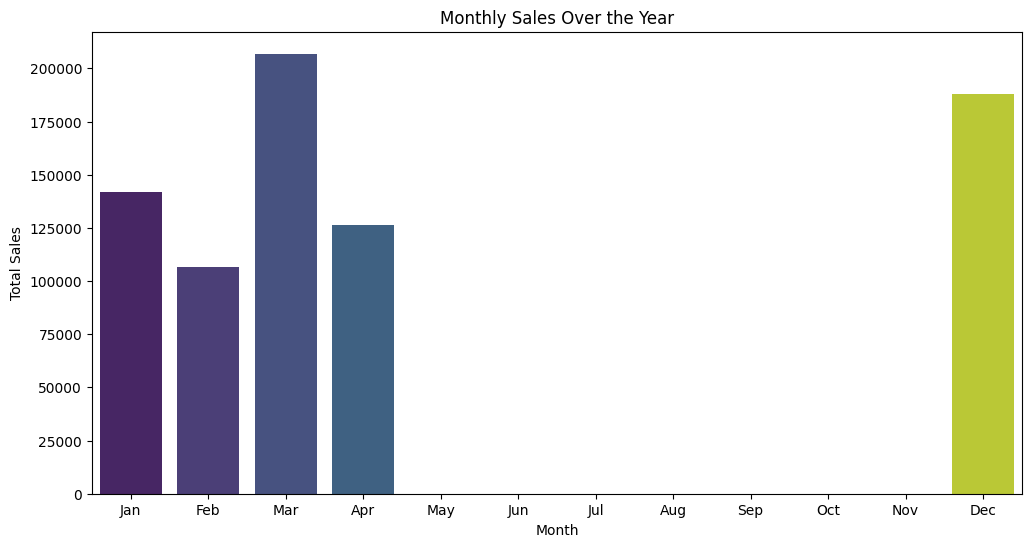

In [ ]:
import calendar

# 1. Create a DataFrame containing all 12 months
all_months_df = pd.DataFrame({'Month': range(1, 13)})

# 2. Merge the month_sales DataFrame with this new DataFrame
# The existing month_sales only has months with sales, need to include all 12
monthly_sales_complete = pd.merge(all_months_df, month_sales, on='Month', how='left').fillna(0)

# 3. Create a dictionary to map month numbers (1-12) to their corresponding three-letter month names
month_name_map = {i: calendar.month_abbr[i] for i in range(1, 13)}

# 4. Add a new column to your merged DataFrame ('Month_Name') by applying this mapping
monthly_sales_complete['Month_Name'] = monthly_sales_complete['Month'].map(month_name_map)

# 5. Create a bar plot using seaborn.barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='Month_Name', y='Price', data=monthly_sales_complete, palette='viridis')

# 6. Add a title to the plot
plt.title('Monthly Sales Over the Year')

# 7. Label the x-axis as 'Month' and the y-axis as 'Total Sales'
plt.xlabel('Month')
plt.ylabel('Total Sales')

# 8. Display the plot
plt.show()

### Corrected Monthly Sales Plot (Warning Resolution)

This cell is an updated version of the previous monthly sales plot code. It specifically addresses a `FutureWarning` issued by the `seaborn` library regarding the use of `palette` without `hue`. By explicitly setting `hue='Month_Name'` and `legend=False` in the `sns.barplot` function call, this code ensures future compatibility and suppresses the warning, while maintaining the same clear visualization of monthly sales with all months represented and named.

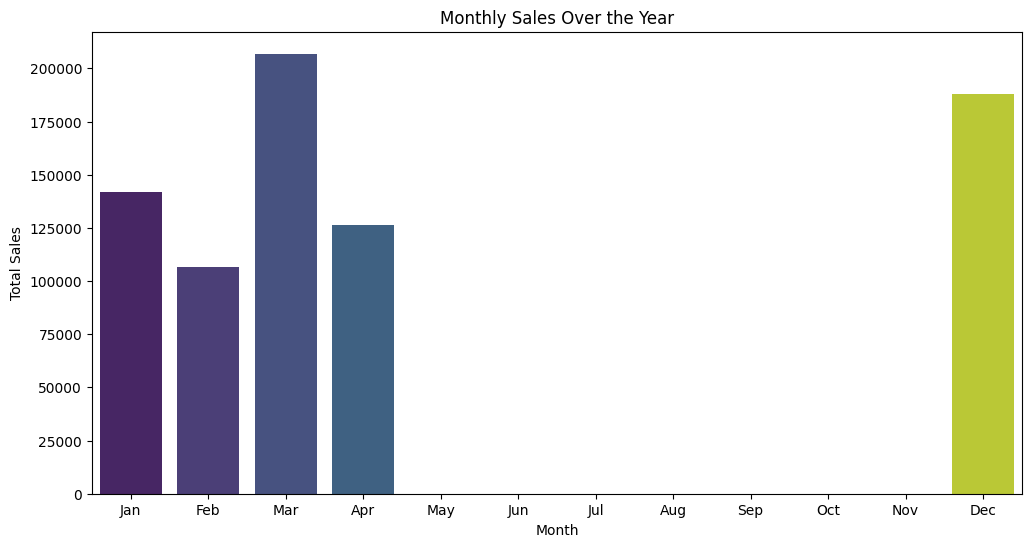

In [ ]:
import calendar

# 1. Create a DataFrame containing all 12 months
all_months_df = pd.DataFrame({'Month': range(1, 13)})

# 2. Merge the month_sales DataFrame with this new DataFrame
# The existing month_sales only has months with sales, need to include all 12
monthly_sales_complete = pd.merge(all_months_df, month_sales, on='Month', how='left').fillna(0)

# 3. Create a dictionary to map month numbers (1-12) to their corresponding three-letter month names
month_name_map = {i: calendar.month_abbr[i] for i in range(1, 13)}

# 4. Add a new column to your merged DataFrame ('Month_Name') by applying this mapping
monthly_sales_complete['Month_Name'] = monthly_sales_complete['Month'].map(month_name_map)

# 5. Create a bar plot using seaborn.barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='Month_Name', y='Price', data=monthly_sales_complete, hue='Month_Name', legend=False, palette='viridis')

# 6. Add a title to the plot
plt.title('Monthly Sales Over the Year')

# 7. Label the x-axis as 'Month' and the y-axis as 'Total Sales'
plt.xlabel('Month')
plt.ylabel('Total Sales')

# 8. Display the plot
plt.show()

## Project Summary: Market Basket Analysis of E-commerce Data

This notebook demonstrates a comprehensive approach to Market Basket Analysis using an online retail dataset. The project involved several key stages:

### 1. Data Loading and Initial Exploration:
- The `online_retail_II.csv` dataset was loaded into a pandas DataFrame.
- Initial data types were inspected, and a preliminary check for missing values was performed.

### 2. Data Preprocessing and Cleaning:
- The `InvoiceDate` column was converted to datetime objects, and granular time features (day, month, year, hour, minute, day of week) were extracted.
- Rows with missing 'Description' values were dropped to ensure data quality for item analysis.
- Transactions with non-positive `Quantity` and those indicative of cancellations (invoice numbers starting with 'C') were filtered out, ensuring the analysis focuses on valid purchases.
- The DataFrame's shape and remaining missing values were verified after cleaning.

### 3. Exploratory Data Analysis (EDA) and Visualization:
- Visualizations were created to understand sales patterns and item popularity:
    - A bar plot of the **Top 10 Most Frequent Items** highlighted the most commonly purchased products.
    - Another bar plot showed the **Most Sold Items by Total Price**, identifying products that contribute most to revenue.
    - **Daily Sales** were plotted to observe short-term sales trends.
    - **Monthly Sales** were visualized, ensuring all 12 months were represented and correctly labeled with month names, and a `FutureWarning` from `seaborn` was addressed for robust plotting.

### 4. Market Basket Analysis Preparation:
- Data was prepared for association rule mining by grouping items by invoice to create transaction lists.
- `mlxtend.preprocessing.TransactionEncoder` was used to perform one-hot encoding, transforming transaction lists into a binary DataFrame.

### 5. Co-occurrence Analysis:
- A **Co-occurrence Heatmap** was generated for the top 20 most frequent items. This visualization effectively shows which items are frequently purchased together, providing valuable insights for cross-selling, product placement, and bundle offers.